# Phase 3b — The Prediction Model: XGBoost + SHAP (plus SQL EDA)

**Author:** Zohair Khan · 2026-07-07

Phase 3a (R) built the *explanation* model. This notebook builds the *prediction* model — gradient boosting —
and answers three questions:

1. **(SQL warm-up)** Do the headline EDA cuts reproduce in plain analytical SQL? (DuckDB over the same CSV)
2. **How much predictive lift** does XGBoost buy over logistic regression on the **same** held-out test set?
3. **Why** does the model flag each individual? (SHAP attribution, which feeds the dashboard's "why" column)

The train/test split is read from `data/train-test-split.csv` (created in R, seed 42, stratified 80/20).
This notebook never re-splits — that's what keeps the Phase 3c comparison honest.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

hr = pd.read_csv("data/hr-attrition.csv")
split = pd.read_csv("data/train-test-split.csv")
df = hr.merge(split, on="EmployeeNumber", validate="one_to_one")

assert len(df) == 1470
assert (df["set"] == "test").sum() == 294
test_rate = df.loc[df["set"] == "test", "Attrition"].eq("Yes").mean()
print(f"test rows: {(df['set']=='test').sum()}, test attrition rate: {test_rate:.3f}")

test rows: 294, test attrition rate: 0.160


## SQL EDA — the headline cuts, in analytical SQL

Same dataset, queried with DuckDB. These are the queries an analyst would run against the HR warehouse
before touching any model.

In [2]:
con = duckdb.connect()
con.register("hr", hr)

q_dept_overtime = """
SELECT Department,
       OverTime,
       COUNT(*)                                            AS n,
       ROUND(AVG(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END), 3) AS attrition_rate
FROM hr
GROUP BY Department, OverTime
ORDER BY attrition_rate DESC
"""
con.sql(q_dept_overtime).df()

,Department,OverTime,n,attrition_rate
0,Sales,Yes,128,0.375
1,Human Resources,Yes,17,0.294
2,Research & Development,Yes,271,0.273
3,Human Resources,No,46,0.152
4,Sales,No,318,0.138
5,Research & Development,No,690,0.086


In [3]:
q_income_quartile = """
WITH banded AS (
  SELECT Attrition,
         NTILE(4) OVER (ORDER BY MonthlyIncome) AS income_quartile
  FROM hr
)
SELECT income_quartile,
       COUNT(*)                                            AS n,
       ROUND(AVG(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END), 3) AS attrition_rate
FROM banded
GROUP BY income_quartile
ORDER BY income_quartile
"""
con.sql(q_income_quartile).df()

,income_quartile,n,attrition_rate
0,1,368,0.293
1,2,368,0.141
2,3,367,0.106
3,4,367,0.104


In [4]:
q_tenure = """
SELECT CASE WHEN YearsAtCompany <= 1 THEN '0-1 yr'
            WHEN YearsAtCompany <= 3 THEN '2-3 yrs'
            WHEN YearsAtCompany <= 6 THEN '4-6 yrs'
            WHEN YearsAtCompany <= 10 THEN '7-10 yrs'
            ELSE '10+ yrs' END                             AS tenure_band,
       COUNT(*)                                            AS n,
       ROUND(AVG(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END), 3) AS attrition_rate
FROM hr
GROUP BY tenure_band
ORDER BY MIN(YearsAtCompany)
"""
con.sql(q_tenure).df()

,tenure_band,n,attrition_rate
0,0-1 yr,215,0.349
1,2-3 yrs,255,0.184
2,4-6 yrs,382,0.128
3,7-10 yrs,372,0.124
4,10+ yrs,246,0.081


In [5]:
q_role = """
SELECT JobRole,
       COUNT(*)                                            AS n,
       ROUND(AVG(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END), 3) AS attrition_rate,
       ROUND(MEDIAN(MonthlyIncome), 0)                     AS median_monthly_income
FROM hr
GROUP BY JobRole
ORDER BY attrition_rate DESC
LIMIT 5
"""
con.sql(q_role).df()

,JobRole,n,attrition_rate,median_monthly_income
0,Sales Representative,83,0.398,2579.0
1,Laboratory Technician,259,0.239,2886.0
2,Human Resources,52,0.231,3093.0
3,Sales Executive,326,0.175,6231.0
4,Research Scientist,292,0.161,2888.0


The SQL cuts confirm the R EDA: overtime roughly triples the attrition rate within every department,
the lowest income quartile leaves at a multiple of the highest, risk concentrates in the first two tenure
years, and Sales Representatives are the standout role (highest attrition, lowest median pay).

## Feature preparation

One-hot encode the nominal variables, drop the constants and the ID, split by the shared file.

In [6]:
TARGET = "Attrition"
DROP = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber", "set"]

X_all = pd.get_dummies(df.drop(columns=DROP + [TARGET]), drop_first=False)
y_all = df[TARGET].eq("Yes").astype(int)

train_mask = df["set"] == "train"
X_train_full, y_train_full = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[~train_mask], y_all[~train_mask]

print(f"features: {X_all.shape[1]}, train: {len(X_train_full)}, test: {len(X_test)}")

features: 51, train: 1176, test: 294


## XGBoost

Class imbalance (16% leavers) is handled with `scale_pos_weight`; overfitting is handled with early
stopping on a validation slice carved from the *training* set only — the test set stays untouched
until final evaluation.

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15,
    stratify=y_train_full, random_state=RANDOM_STATE)

spw = (y_tr == 0).sum() / (y_tr == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=2,
    scale_pos_weight=spw,
    eval_metric="auc",
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f"scale_pos_weight: {spw:.2f}, best iteration: {model.best_iteration}")

scale_pos_weight: 5.20, best iteration: 38


## Held-out performance (same test set, same metrics as the R model)

In [8]:
test_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, test_prob)
brier = brier_score_loss(y_test, test_prob)
pred = (test_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()

decile_n = int(np.ceil(0.10 * len(test_prob)))
top_idx = np.argsort(test_prob)[::-1][:decile_n]
capture = y_test.iloc[top_idx].sum() / y_test.sum()
lift = capture / 0.10

metrics = pd.DataFrame([{
    "model": "xgboost_python",
    "auc": auc,
    "brier": brier,
    "accuracy": (tp + tn) / cm.sum(),
    "precision_at_0.5": tp / (tp + fp),
    "recall_at_0.5": tp / (tp + fn),
    "top_decile_capture": capture,
    "top_decile_lift": lift,
    "n_test": len(test_prob),
    "n_test_leavers": int(y_test.sum()),
}])
metrics.to_csv("outputs/xgb-metrics.csv", index=False)
print(f"confusion matrix (rows=actual, cols=predicted):\n{cm}")
metrics.round(3)

confusion matrix (rows=actual, cols=predicted):
[[207  40]
 [ 16  31]]


,model,auc,brier,accuracy,precision_at_0.5,recall_at_0.5,top_decile_capture,top_decile_lift,n_test,n_test_leavers
0,xgboost_python,0.825,0.184,0.81,0.437,0.66,0.426,4.255,294,47


## SHAP — why the model flags who it flags

Global view first (which features drive predictions across everyone), then the per-employee attribution
that feeds the dashboard's "top driver" column.

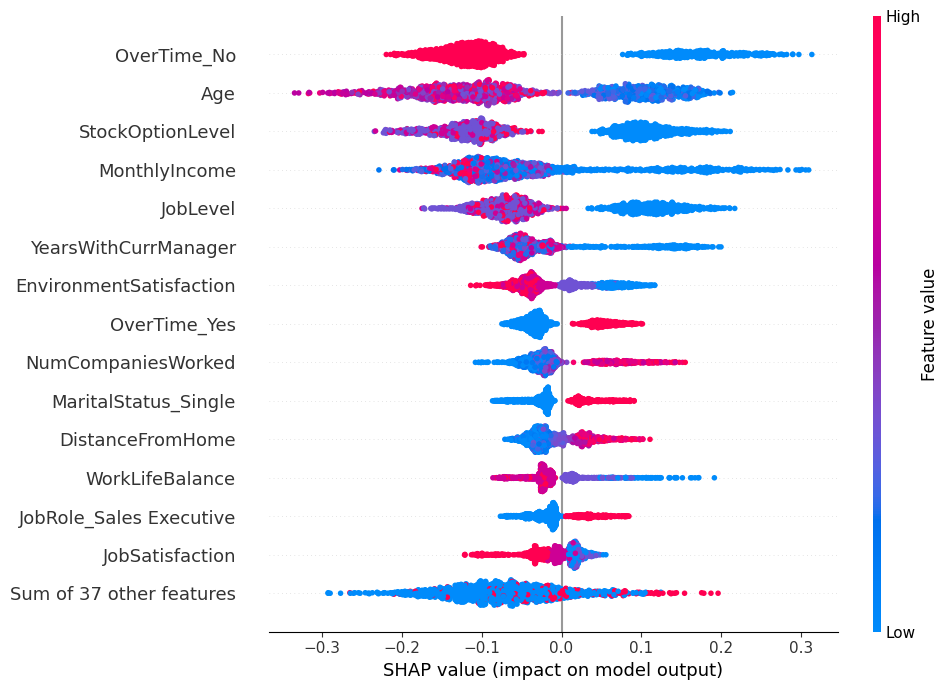

In [9]:
explainer = shap.Explainer(model)
explanation = explainer(X_all)

shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.savefig("outputs/figures/shap-summary.png", dpi=150, bbox_inches="tight")
plt.show()

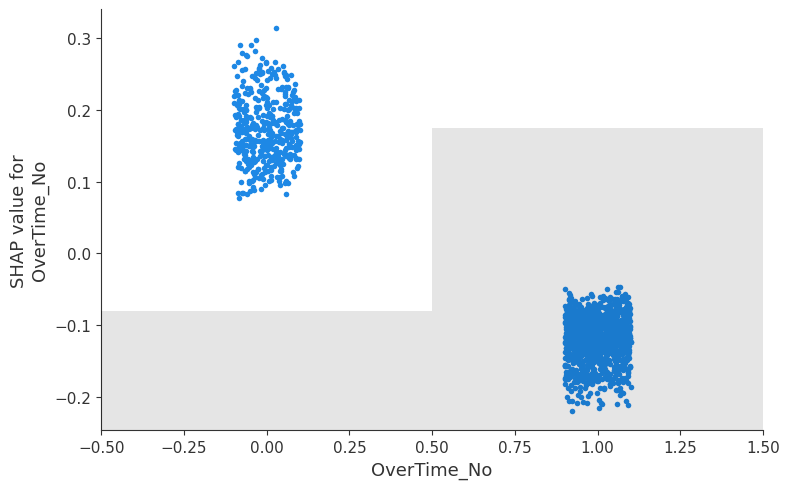

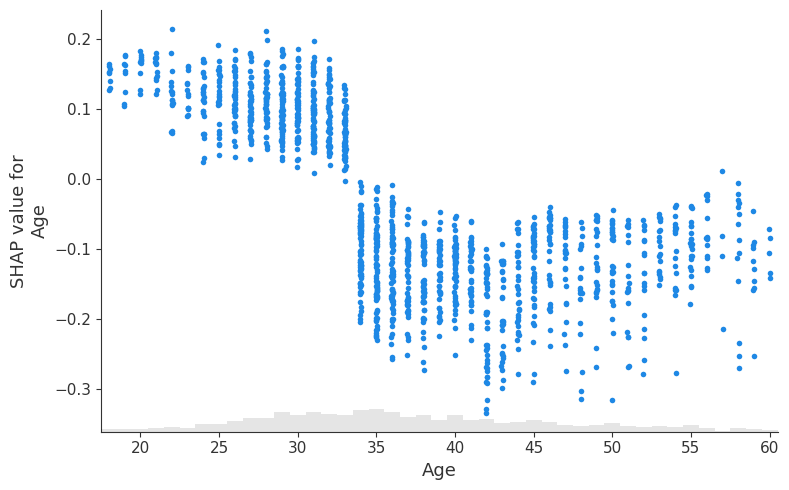

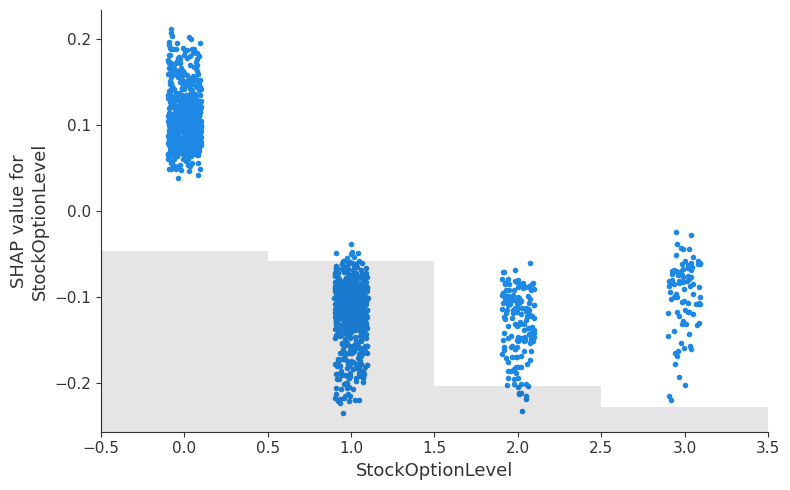

top 3 features by mean |SHAP|: ['OverTime_No', 'Age', 'StockOptionLevel']


In [10]:
mean_abs = np.abs(explanation.values).mean(axis=0)
top3 = X_all.columns[np.argsort(mean_abs)[::-1][:3]]
for feat in top3:
    shap.plots.scatter(explanation[:, feat], show=False)
    plt.gcf().set_size_inches(8, 5)
    plt.tight_layout()
    safe = feat.replace(" ", "-").replace("/", "-")
    plt.savefig(f"outputs/figures/shap-dependence-{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()
print("top 3 features by mean |SHAP|:", list(top3))

## Score every employee → the dashboard extract

**Data dictionary — read this before using the extract.** Two models contribute, deliberately and
with a strict division of labor:

- `risk_score`, `risk_decile` — the **decision score**: the R logistic regression's predicted
  probability (read from `outputs/logreg-scores.csv`, produced by `03-model-R.Rmd`). It is the
  better-ranked and better-calibrated model on the shared test set (see `05-model-comparison.md`),
  and it is the model behind the README/memo headline (49% capture in the top decile), so the
  dashboard and the headline are the same model. Decile 10 = riskiest.
- `xgb_score`, `top_shap_driver` — **companion GBM diagnostics**: XGBoost's score and, per employee,
  the source variable with the largest absolute SHAP value. The SHAP column is a pattern-discovery
  view whose driver story agrees with the logistic model; it is *not* the explanation of
  `risk_score`.

Scores cover all 1,470 employees, so training rows are scored in-sample: this extract is a
**retrospective demonstration** of what a watch list would look like, not a deployment artifact
(a real deployment would retrain on all labeled history and score an unlabeled current roster).

In [11]:
CAT_COLS = [c for c in hr.columns if hr[c].dtype == object and c != "Attrition"]

def to_original(col: str) -> str:
    for cat in CAT_COLS:
        if col.startswith(cat + "_"):
            return cat
    return col

feature_origin = np.array([to_original(c) for c in X_all.columns])
top_driver = feature_origin[np.abs(explanation.values).argmax(axis=1)]

logreg_scores = pd.read_csv("outputs/logreg-scores.csv")

scores = df[["EmployeeNumber", "set", "Attrition", "Department", "JobRole",
             "OverTime", "MonthlyIncome", "Age", "YearsAtCompany",
             "JobSatisfaction"]].copy()
scores = scores.merge(logreg_scores, on="EmployeeNumber", validate="one_to_one")
scores = scores.rename(columns={"logreg_score": "risk_score"})
scores["risk_decile"] = pd.qcut(scores["risk_score"].rank(method="first"),
                                10, labels=range(1, 11)).astype(int)
scores["xgb_score"] = model.predict_proba(X_all)[:, 1].round(4)
scores["top_shap_driver"] = top_driver

scores.to_csv("outputs/attrition-risk-scores.csv", index=False)
print(scores["risk_decile"].value_counts().sort_index().to_dict())
scores.sort_values("risk_score", ascending=False).head(10)

{1: 147, 2: 147, 3: 147, 4: 147, 5: 147, 6: 147, 7: 147, 8: 147, 9: 147, 10: 147}


,EmployeeNumber,set,Attrition,Department,JobRole,OverTime,MonthlyIncome,Age,YearsAtCompany,JobSatisfaction,risk_score,risk_decile,xgb_score,top_shap_driver
463,622,train,Yes,Research & Development,Laboratory Technician,Yes,2340,26,1,4,0.9813,10,0.7369,MonthlyIncome
357,478,test,Yes,Sales,Sales Representative,Yes,2174,21,3,2,0.9777,10,0.6951,OverTime
1060,1494,train,Yes,Research & Development,Laboratory Technician,Yes,3172,24,0,1,0.9618,10,0.7129,Age
911,1273,train,Yes,Sales,Sales Representative,Yes,1118,25,1,4,0.9513,10,0.7316,MonthlyIncome
457,614,train,Yes,Sales,Sales Representative,Yes,1878,18,0,2,0.9455,10,0.7106,OverTime
1057,1487,train,Yes,Sales,Sales Executive,No,5765,29,5,2,0.9381,10,0.6516,StockOptionLevel
798,1108,test,Yes,Research & Development,Research Scientist,Yes,2313,33,2,2,0.9221,10,0.6606,OverTime
656,911,train,Yes,Research & Development,Laboratory Technician,Yes,2795,32,1,4,0.9185,10,0.6644,JobLevel
127,167,test,Yes,Sales,Sales Representative,Yes,1675,19,0,3,0.9055,10,0.7070,MonthlyIncome
1396,1968,train,Yes,Sales,Sales Executive,Yes,10448,53,2,1,0.9050,10,0.6471,OverTime


## Takeaways

- The SQL cuts, the R tests, and SHAP all converge on the same driver story — overtime, early tenure,
  low income/level, and the sales-rep role — which is what you want before recommending action.
- XGBoost's edge over logistic regression (or lack of one) is quantified in `05-model-comparison.md`,
  on identical test data; on this split, logistic regression ranked and calibrated better.
- `outputs/attrition-risk-scores.csv` is the Tableau feed: logistic decision score + decile, plus
  labeled companion-GBM diagnostics (`xgb_score`, `top_shap_driver`).